In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
import skimage as ski
from PIL import Image
import cv2
from skimage.filters import sato

In [2]:
IMAGE_ID = 'S1585-2_a'
ROI_X = 4820
ROI_Y = 1710
ROI_W = 128
ROI_H = 256


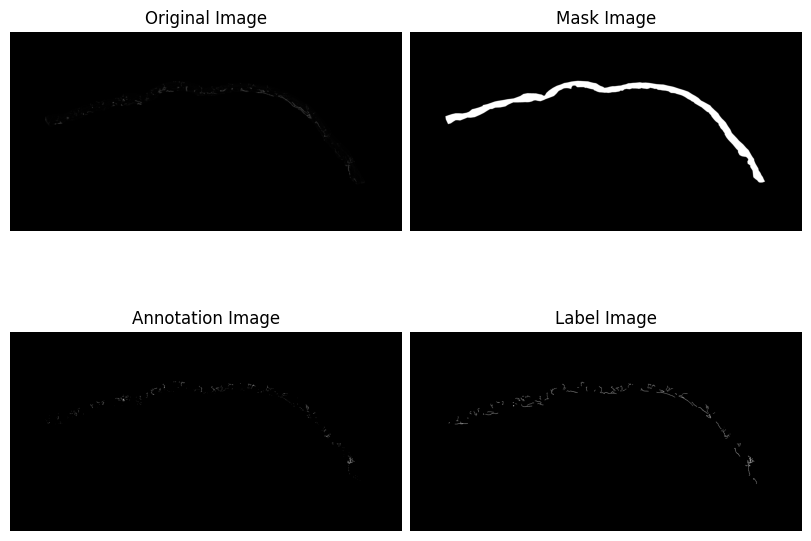

In [3]:
base_path = f"../data/{IMAGE_ID}/"

orig_img = cv2.imread(f"{base_path}/roi_image.png",cv2.IMREAD_GRAYSCALE)
mask_img = cv2.imread(f"{base_path}/mask.png", cv2.IMREAD_GRAYSCALE)
annotation_img = cv2.imread(f"{base_path}/roi_annotation.png", cv2.IMREAD_GRAYSCALE)
label_img = cv2.imread(f"{base_path}/label.png", cv2.IMREAD_GRAYSCALE)

_, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 6), constrained_layout=True)
axes[0, 0].imshow(orig_img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].set_axis_off()
axes[0, 1].imshow(mask_img, cmap='gray')
axes[0, 1].set_title('Mask Image')
axes[0, 1].set_axis_off()
axes[1, 0].imshow(annotation_img, cmap='gray')
axes[1, 0].set_title('Annotation Image')
axes[1, 0].set_axis_off()
axes[1, 1].imshow(label_img, cmap='gray')
axes[1, 1].set_title('Label Image')
axes[1, 1].set_axis_off()
plt.show()

Total components detected: 621


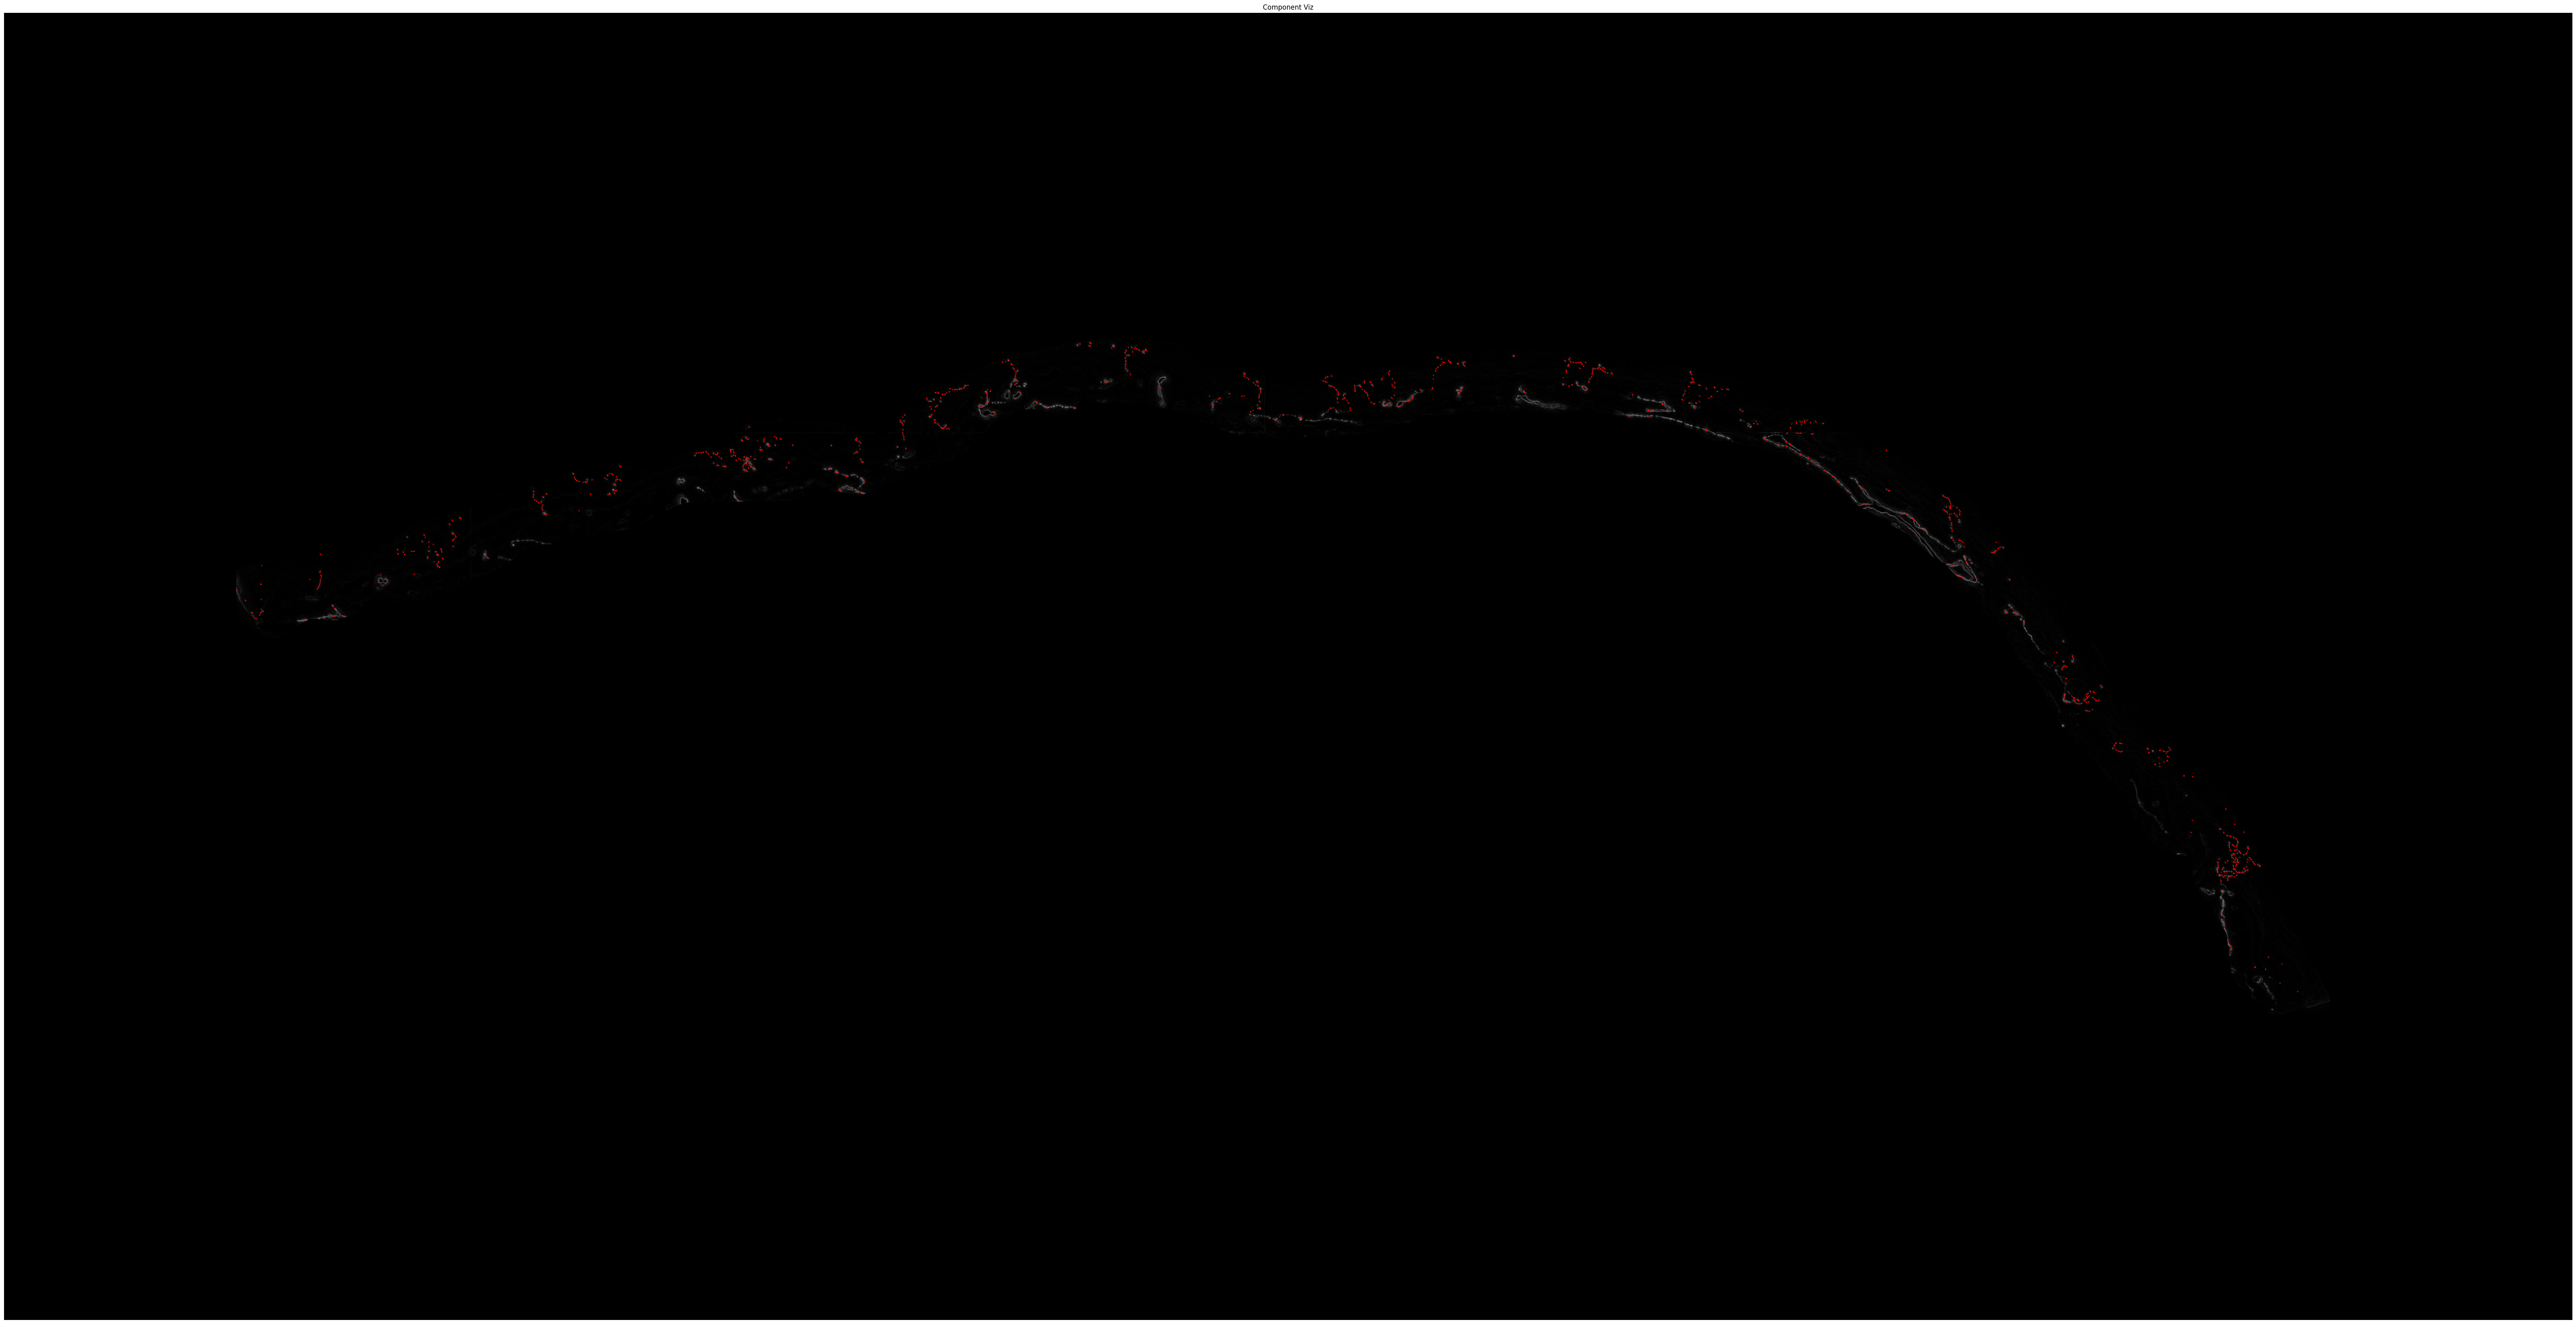

In [4]:
import cv2
from skimage.measure import label, regionprops
from neural_reconstruction.core.construction.component_analyzer import ComponentAnalyzer
from neural_reconstruction.common.data_types import ComponentAnalysisResult
from typing import List

annotation_mask = (annotation_img > 0).astype(np.uint8)
labeled_image = label(annotation_mask, connectivity=1)
regions = regionprops(labeled_image)


component_analyzer = ComponentAnalyzer(
    segment_length=5,
    min_edge_length=0,
    prune_threshold=0,
    spacing=0,
)

component_list:List[ComponentAnalysisResult] =[]
for region in regions:
	component_analyze_res = component_analyzer.analyze(region)
	component_list.append(component_analyze_res)


print(f"Total components detected: {len(component_list)}")

# Viz first five components

fig_size = 64
num_fig = 1
_, axes = plt.subplots(nrows=num_fig, ncols=1, figsize=(fig_size, fig_size * num_fig), constrained_layout=True)
component_image =cv2.cvtColor(orig_img.copy(), cv2.COLOR_GRAY2BGR)

seed_points = []
axes.imshow(component_image)
# for i in range(10):
for component in component_list:
	# component = component_list[i]
	bbox = component.bbox  # (min_row, min_col, max_row, max_col)
	min_row, min_col, max_row, max_col = bbox


	for node in component.topology.nodes():
		py, px = node
		py += min_row
		px += min_col

		seed_points.append((py, px))
		
		axes.plot(px, py, 'ro', markersize=1)
	for u, v, data in component.topology.edges(data=True):
		
		path = data['path']
		py = []
		px = []

		for y_i, x_i in path:
			py.append(y_i + min_row)
			px.append(x_i + min_col)
		axes.plot(px, py, color='red', alpha=1, linewidth=0.7)
axes.set_title(f'Component Viz')
axes.set_axis_off()

plt.show()

In [5]:
from scipy.spatial import KDTree

# 參數設定
SEARCH_RADIUS = 20  # 搜尋半徑

# 將 selected_points 轉換為 numpy array
topology_points = []
component_lookup = {}
pairings = {}
for idx, component in enumerate(component_list):
	# component = component_list[i]
	bbox = component.bbox  # (min_row, min_col, max_row, max_col)
	min_row, min_col, max_row, max_col = bbox


	for node in component.topology.nodes():
		py, px = node
		py += min_row
		px += min_col

		topology_points.append((py, px))
		component_lookup[(py, px)] = idx
	for u, v, data in component.topology.edges(data=True):
		path = data['path']
		global_path = [(y_i + min_row, x_i + min_col) for y_i, x_i in path]
		u_global = (u[0] + min_row, u[1] + min_col)
		v_global = (v[0] + min_row, v[1] + min_col)
		pairings[(u_global, v_global)] = (global_path, 1e-5)


topology_points = np.array(topology_points)

# 建構 KDTree
kdtree = KDTree(topology_points)
print(f"KDTree built with {len(topology_points)} points")
print(f"Search radius: {SEARCH_RADIUS}s")

KDTree built with 1350 points
Search radius: 20s


In [6]:
# Find very pairings 
# cost_map = (255 - orig_img.astype(np.float64))**2 / 255**2
cost_map = (255 - orig_img.astype(np.float64)) / 255.0
cost_map_h, cost_map_w = cost_map.shape

path_finding_bbox_padding = 10

for u_idx in range(len(topology_points)):
	search_radius = SEARCH_RADIUS
	# 在 KDTree 中搜尋鄰近點
	u = topology_points[u_idx]
    
    # 查詢半徑內的所有鄰居
	neighbor_indices = kdtree.query_ball_point(u, r=search_radius)
	targets = [topology_points[v_idx] for v_idx in neighbor_indices]

    # 排除自己
	targets = [target for target in targets if tuple(target) != tuple(u)]

	# neighbor_indices = [idx for idx in neighbor_indices if idx != u_idx]
    # # 排除屬於同一個 component 的點
	
	current_component_id = component_lookup[tuple(u)]
	targets = [target for target in targets if component_lookup[tuple(target)] != current_component_id]
	# neighbor_indices = [idx for idx in neighbor_indices if component_lookup[tuple(topology_points[idx])] != current_component_id]
    
	# # 排除已存在的配對
	# neighbor_indices = [idx for idx in neighbor_indices if (tuple(u), tuple(topology_points[idx])) not in pairings and (tuple(topology_points[idx]), tuple(u)) not in pairings]
	targets = [target for target in targets if (tuple(u), tuple(target)) not in pairings and (tuple(target), tuple(u)) not in pairings]

	# 計算包含所有點的最小 bbox + padding
	all_points = [u] + targets
	all_y = [p[0] for p in all_points]
	all_x = [p[1] for p in all_points]

	min_y = max(0, min(all_y) - path_finding_bbox_padding)
	max_y = min(cost_map_h - 1, max(all_y) + path_finding_bbox_padding)
	min_x = max(0, min(all_x) - path_finding_bbox_padding)
	max_x = min(cost_map_w - 1, max(all_x) + path_finding_bbox_padding)

	cropped_cost_map = cost_map[min_y : max_y + 1, min_x : max_x + 1]

	
	local_points = [(pos_global[0] - min_y, pos_global[1] - min_x) for pos_global in all_points]
	mcp = ski.graph.MCP_Geometric(cropped_cost_map, fully_connected=True)
	cumulative_costs, traceback = mcp.find_costs(starts=local_points[:1], ends=local_points[1:])
	for target in local_points[1:]:
		if np.isinf(cumulative_costs[target]):
			continue

		path = mcp.traceback(target)
		cost = cumulative_costs[target]
		path_arr = np.array(path)
		diffs = np.diff(path_arr, axis=0)
		segment_dists = np.linalg.norm(diffs, axis=1)
		path_length = np.sum(segment_dists)
		# 轉換回全局座標
		global_path = [(p[0] + min_y, p[1] + min_x) for p in path]
		global_start = (u[0], u[1])
		global_target = (target[0] + min_y, target[1] + min_x)
		# normalized_cost = cost / path_length
		normalized_cost = cost / 1

		if (global_target, global_start) in pairings:
			min_cost = min(pairings[(global_target, global_start)][1], normalized_cost)
			pairings[(global_target, global_start)] = (global_path, min_cost)
		else:
			pairings[(global_start, global_target)] = (global_path, normalized_cost)


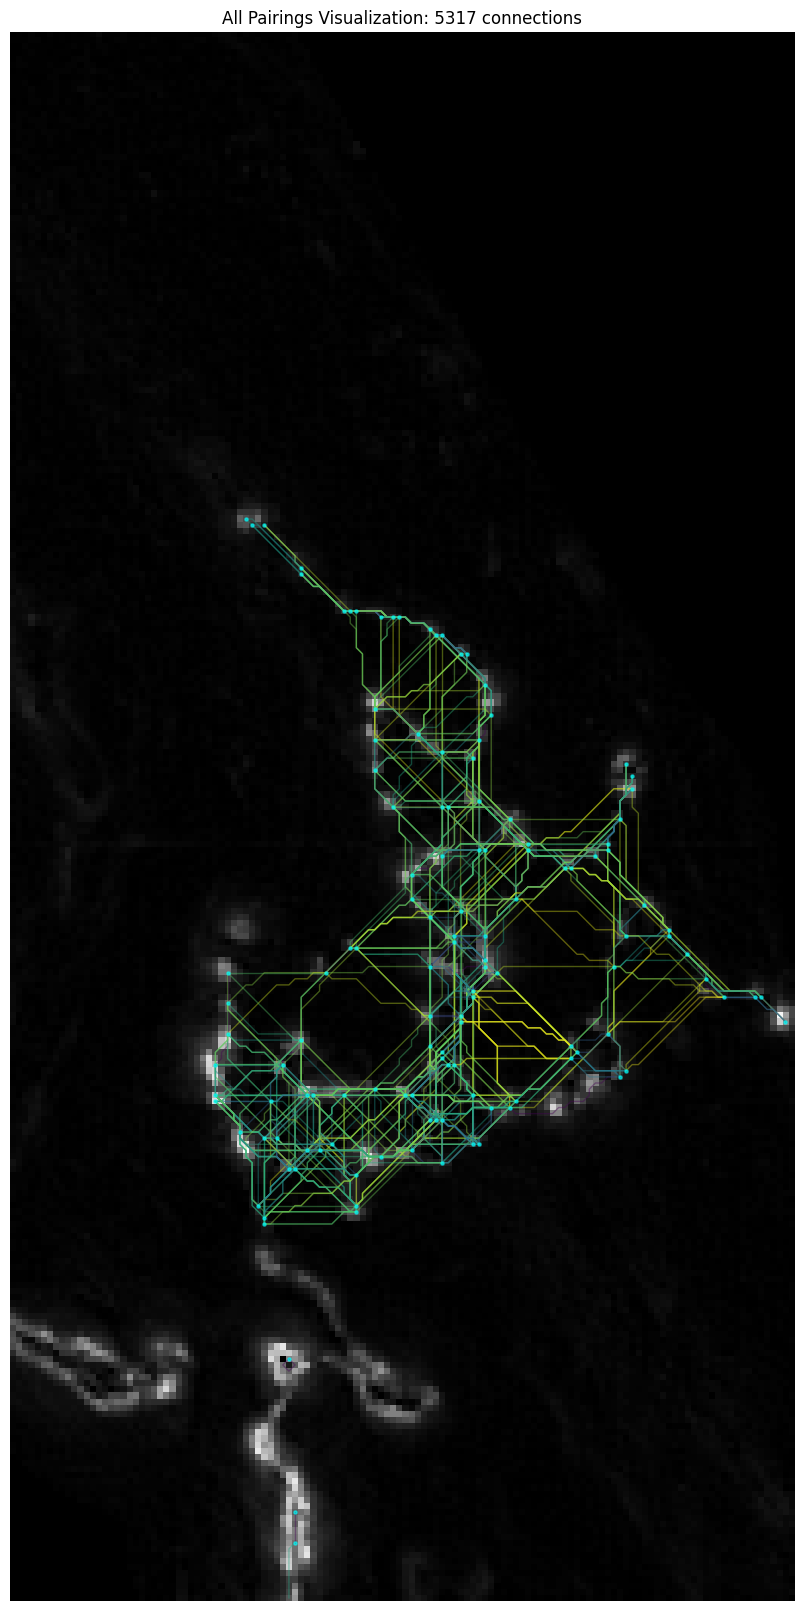


=== 視覺化統計 ===
總連接數: 5317
涉及種子數: 1247
成本範圍: [0.00, 21.02]


In [7]:

fig_size = 32
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(fig_size, fig_size // 2), constrained_layout=True)

# 繪製背景圖片
ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')

# 繪製所有種子點
unique_seeds = set()
for (p1, p2), (path, cost) in pairings.items():
    unique_seeds.add(p1)
    unique_seeds.add(p2)

unique_seeds = list(unique_seeds)
roi_seeds = [(s[0], s[1]) for s in unique_seeds if s[0] > ROI_Y and s[0] < ROI_Y + ROI_H and s[1] > ROI_X and s[1] < ROI_X + ROI_W]
seed_y = [s[0] - ROI_Y for s in roi_seeds]
seed_x = [s[1] - ROI_X for s in roi_seeds]
ax.scatter(seed_x, seed_y, c='cyan', s=5, alpha=0.6, zorder=2, label='Seeds')

# 繪製所有連接路徑
# 使用成本來決定顏色（從藍色到紅色）
all_costs = [cost for _, (path, cost) in pairings.items()]
min_cost = min(all_costs)
max_cost = max(all_costs)

# 使用 colormap
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

norm = Normalize(vmin=min_cost, vmax=max_cost)
cmap = plt.cm.viridis  # 可以選擇其他 colormap: 'viridis', 'plasma', 'inferno', 'coolwarm'

for (p1, p2), (path, cost) in pairings.items():
    if path and len(path) > 1:
        # 繪製路徑
        roi_path = [(p[0], p[1]) for p in path if p[0] > ROI_Y and p[0] < ROI_Y + ROI_H and p[1] > ROI_X and p[1] < ROI_X + ROI_W]
        py = [p[0] - ROI_Y for p in roi_path]
        px = [p[1] - ROI_X for p in roi_path]
        
        # 根據成本決定顏色
        color = cmap(norm(cost))
        ax.plot(px, py, color=color, alpha=0.4, linewidth=1, zorder=1)

ax.set_title(f'All Pairings Visualization: {len(pairings)} connections')
ax.set_axis_off()

plt.show()

# 輸出統計資訊
print(f"\n=== 視覺化統計 ===")
print(f"總連接數: {len(pairings)}")
print(f"涉及種子數: {len(unique_seeds)}")
print(f"成本範圍: [{min_cost:.2f}, {max_cost:.2f}]")

Total sub-trees detected: 72


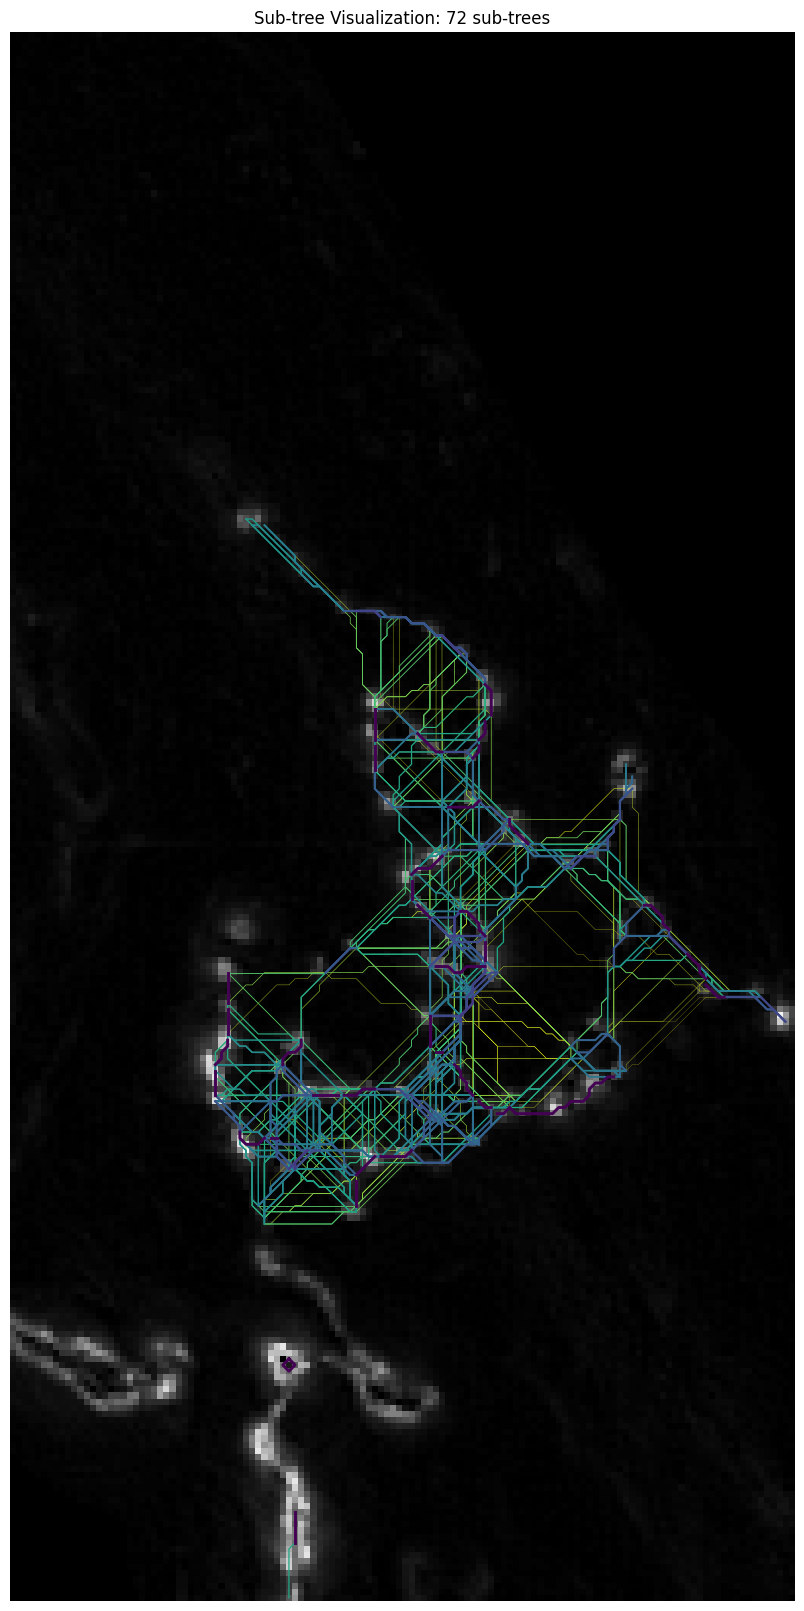

In [8]:
import networkx as nx
graph = nx.Graph()

for (p1, p2), (path, cost) in pairings.items():
	graph.add_edge(p1, p2, weight=cost, path=path)

sub_trees = list(nx.connected_components(graph))
print(f"Total sub-trees detected: {len(sub_trees)}")

fig_size = 32
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(fig_size, fig_size // 2), constrained_layout=True)
# 繪製背景圖片
ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')

# 繪製所有種子點
for idx, component in enumerate(sub_trees):
	subgraph = graph.subgraph(component)

	component_points = list(component)
	roi_points = [(p[0], p[1]) for p in component_points if p[0] > ROI_Y and p[0] < ROI_Y + ROI_H and p[1] > ROI_X and p[1] < ROI_X + ROI_W]
	py = [p[0] - ROI_Y for p in roi_points]
	px = [p[1] - ROI_X for p in roi_points]
	# ax.scatter(px, py, s=10, alpha=0.6, color='r', label=f'Component {idx+1}')
	# comp_color = colors[idx]

	sorted_edges = sorted(subgraph.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
	for u,v,data in sorted_edges:
		path = data['path']
		roi_path = [(p[0], p[1]) for p in path if p[0] > ROI_Y and p[0] < ROI_Y + ROI_H and p[1] > ROI_X and p[1] < ROI_X + ROI_W]
		py_path = [p[0] - ROI_Y for p in roi_path]
		px_path = [p[1] - ROI_X for p in roi_path]

		color = cmap(norm(data['weight']))
		width = 2.0 * (1 - (data['weight'] - min_cost) / (max_cost - min_cost)) + 0.1  # 最小寬度為 0.1
		ax.plot(px_path, py_path, color=color, alpha=1, linewidth=width)


	# # 繪製所有連接路徑
	# for i in range(len(component_points)):
	# 	for j in range(i + 1, len(component_points)):
	# 		p1 = component_points[i]
	# 		p2 = component_points[j]
	# 		if graph.has_edge(p1, p2):
	# 			path = graph[p1][p2]['path']
	# 			if path and len(path) > 1:
	# 				roi_path = [(p[0], p[1]) for p in path if p[0] > ROI_Y and p[0] < ROI_Y + ROI_H and p[1] > ROI_X and p[1] < ROI_X + ROI_W]
	# 				py_path = [p[0] - ROI_Y for p in roi_path]
	# 				px_path = [p[1] - ROI_X for p in roi_path]
	# 				ax.plot(px_path, py_path, color=comp_color, alpha=0.2, linewidth=0.5)
ax.set_title(f'Sub-tree Visualization: {len(sub_trees)} sub-trees')
ax.set_axis_off()
plt.show()


In [9]:
# mst tree
mst_trees = []
for idx, component in enumerate(sub_trees):
    subgraph = graph.subgraph(component)
    mst = nx.minimum_spanning_tree(subgraph, weight="weight")
    mst_trees.append(mst)

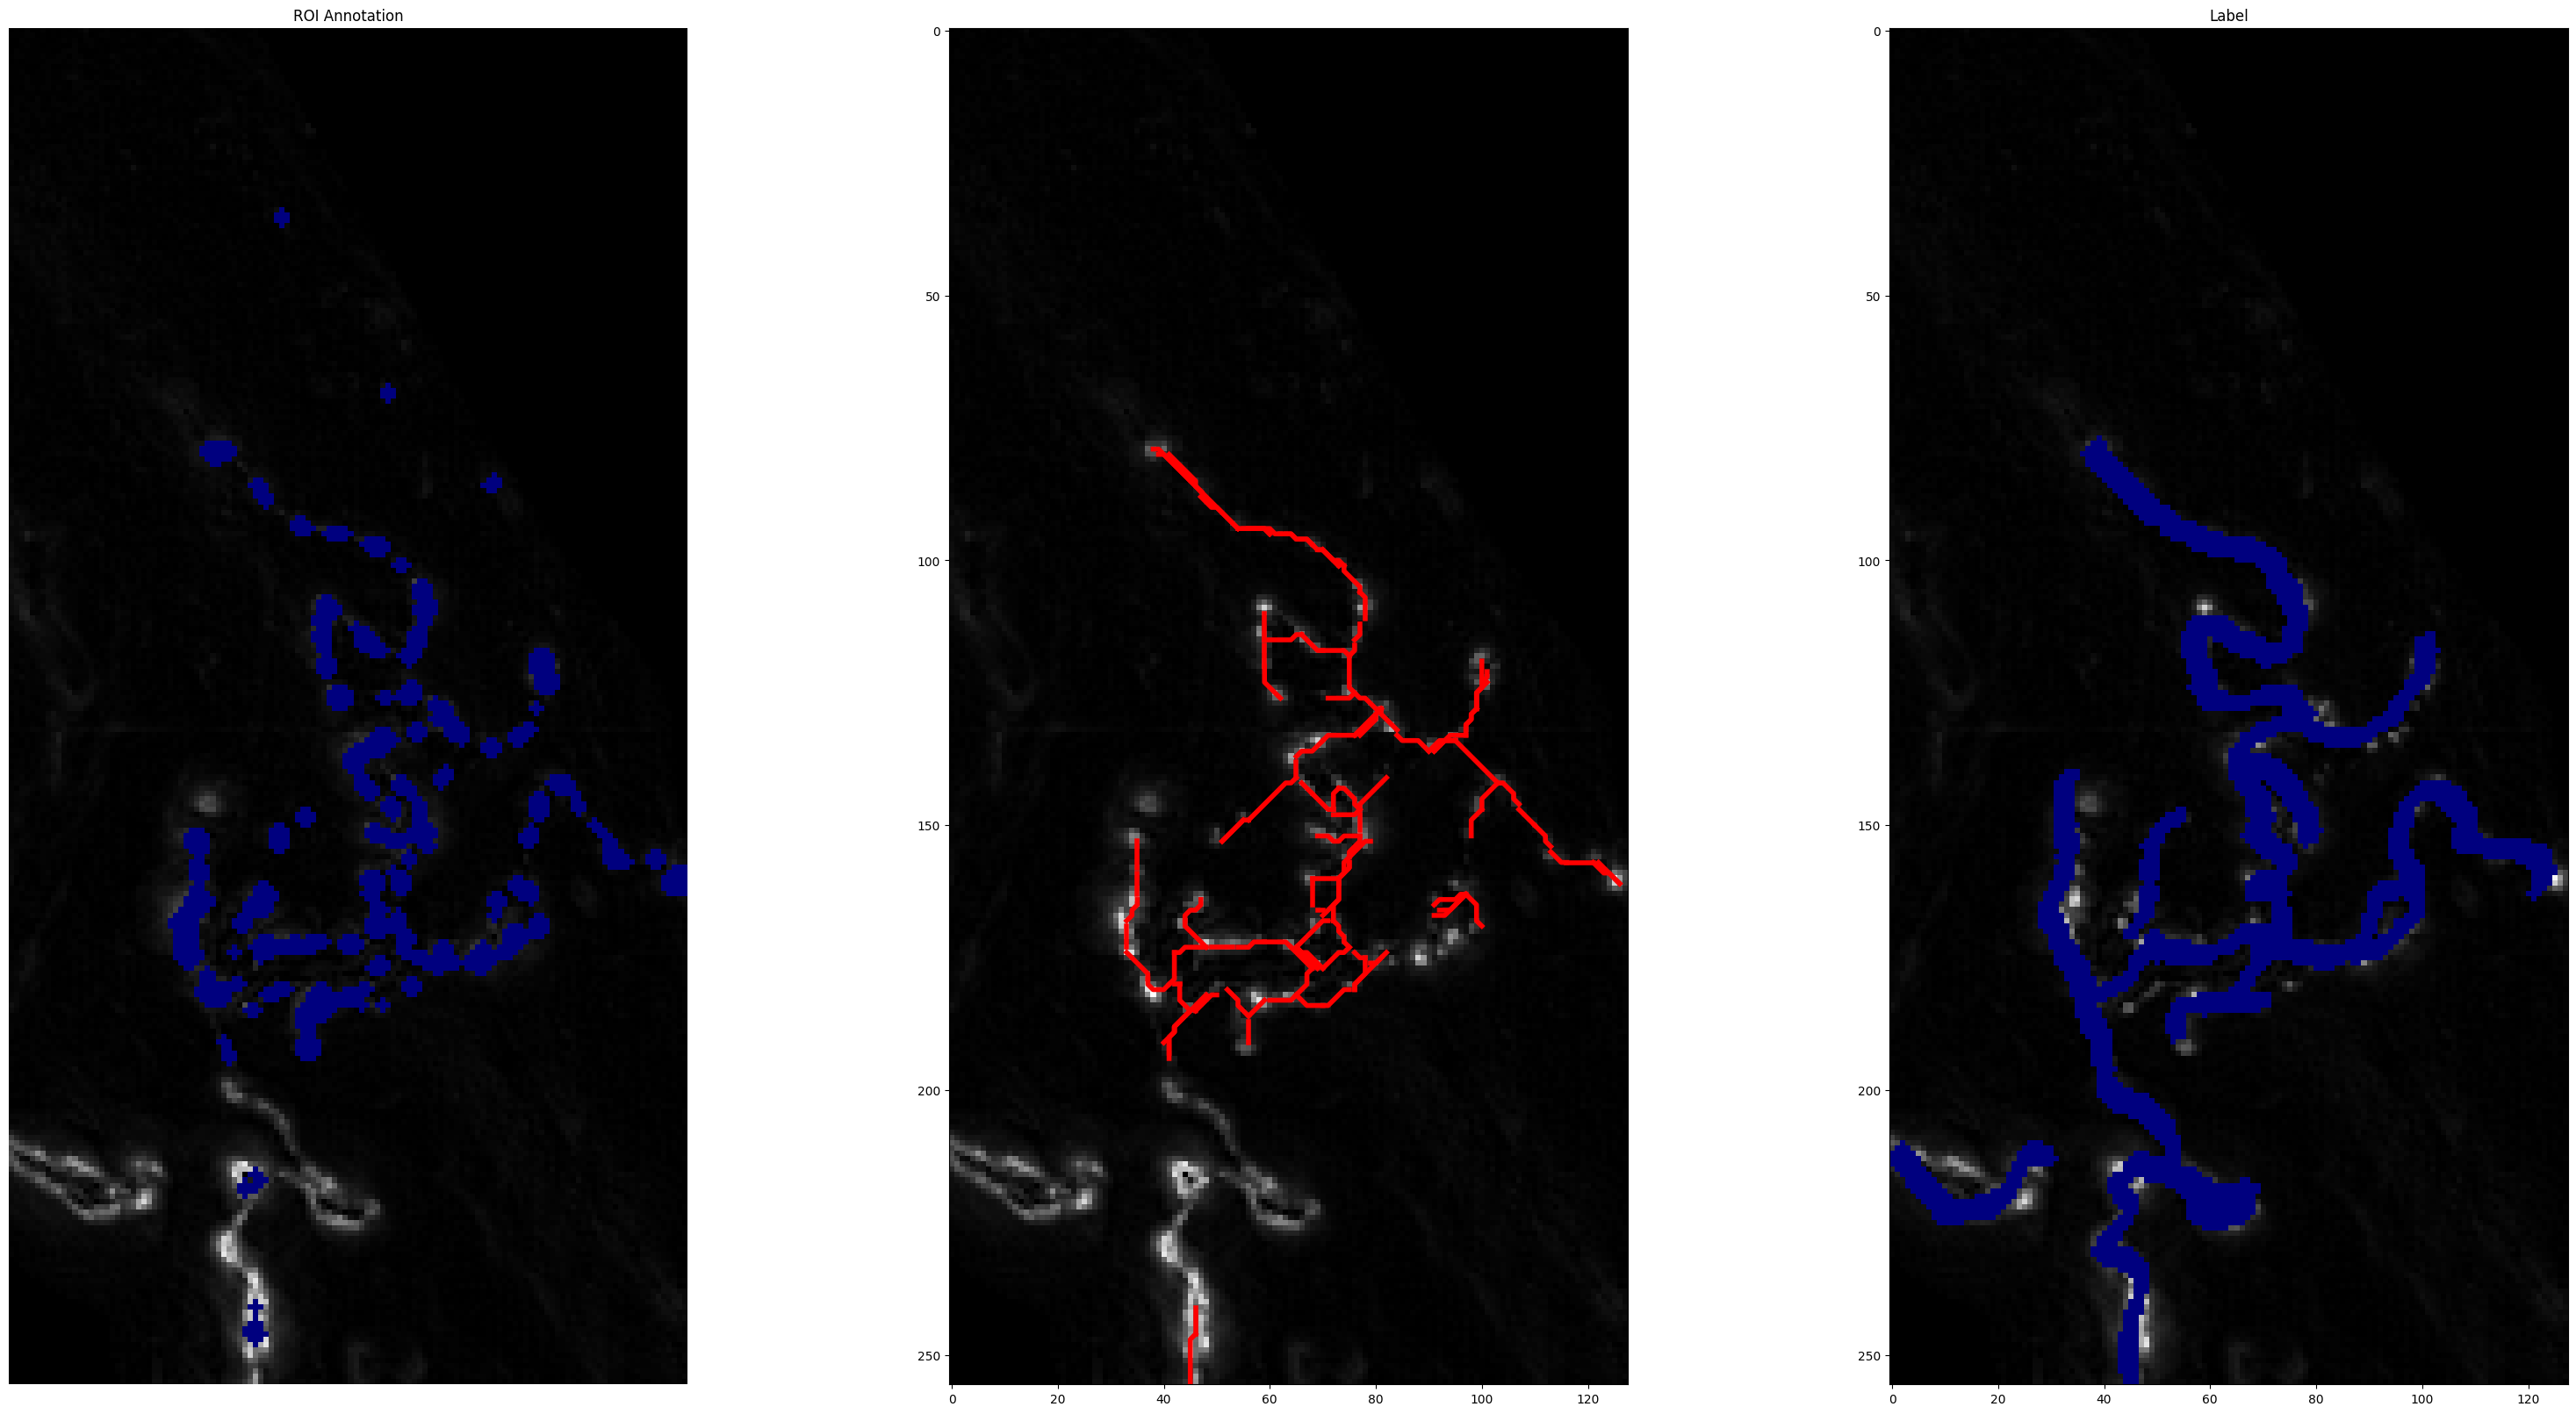

In [10]:
_, ax = plt.subplots(1, 3, figsize=(32, 16), constrained_layout=True)

annotation_ax = ax[0]
annotation_ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')
annotation_ax.imshow(np.ma.masked_where(annotation_img==0, annotation_img)[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='jet', alpha=1)

annotation_ax.set_title("ROI Annotation")
annotation_ax.axis('off')

label_ax = ax[2]
label_ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')
label_ax.imshow(np.ma.masked_where(label_img==0, label_img)[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='jet', alpha=1)
label_ax.set_title("Label")

tree_ax = ax[1]
tree_ax.imshow(orig_img[ROI_Y:ROI_Y+ROI_H, ROI_X:ROI_X+ROI_W], cmap='gray')
for mst_tree in mst_trees:
    for u, v, data in mst_tree.edges(data=True):
        # Nodes are expected to be (y, x) tuples from global topology
        y1, x1 = u
        y2, x2 = v

        
        pt1 = (int(x1), int(y1))
        pt2 = (int(x2), int(y2))

        # If edge data has 'path', draw the full path
        if "path" in data and data["path"]:
            path_points = data["path"]
            # Draw path segments
            py = []
            px = []

            for y_i, x_i in path_points:
                if y_i < ROI_Y or y_i >= ROI_Y + ROI_H or x_i < ROI_X or x_i >= ROI_X + ROI_W:
                    continue
                py.append(y_i - ROI_Y)
                px.append(x_i - ROI_X)

            tree_ax.plot(px, py, color='red', alpha=1, linewidth=4)

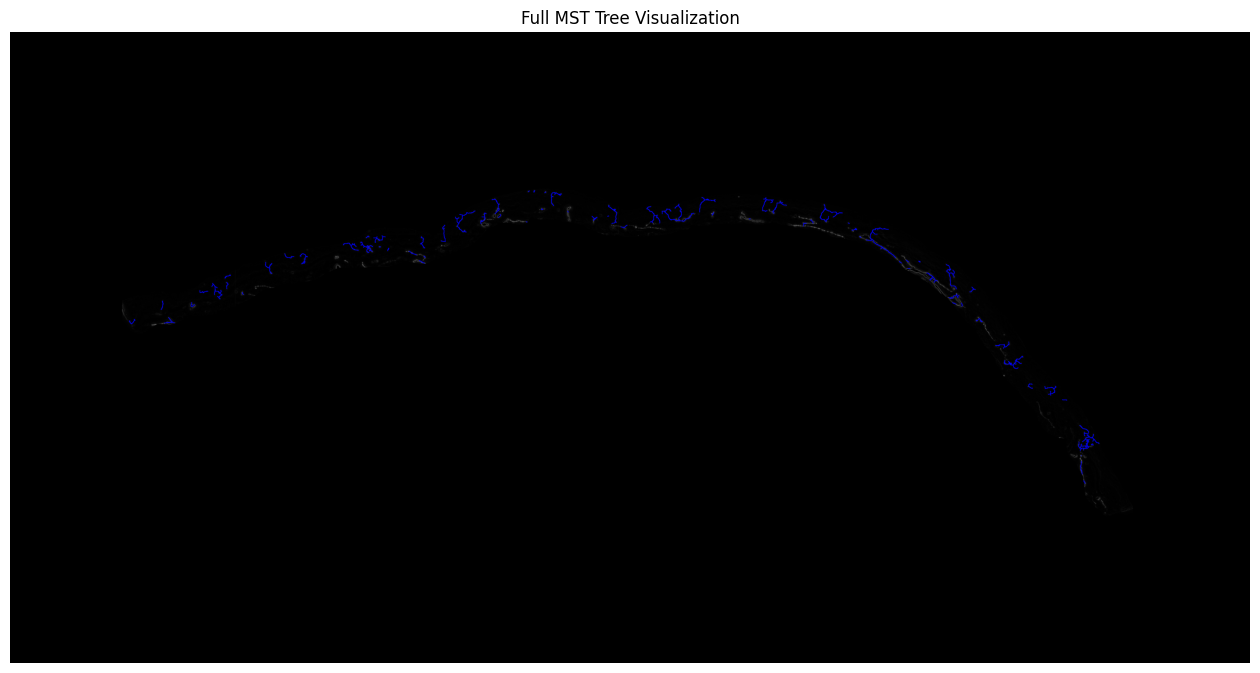

In [11]:
# Full MST Tree Visualization
viz_img =cv2.cvtColor(orig_img.copy(), cv2.COLOR_GRAY2BGR)
for mst_tree in mst_trees:
	points = list(mst_tree.nodes())
	cv2.circle(viz_img, (int(points[0][1]), int(points[0][0])), 2, (0,0,255), -1)
	for u, v, data in mst_tree.edges(data=True):
		path_points = data["path"]
		# Draw path segments
		py = []
		px = []

		for y_i, x_i in path_points:
			py.append(y_i)
			px.append(x_i)
		
		cv2.polylines(viz_img, [np.array(path_points)[:,[1,0]].reshape(-1, 1, 2)], False, (0,0,255), 2)

plt.figure(figsize=(16, 16))
plt.imshow(viz_img)

plt.title("Full MST Tree Visualization")
plt.axis('off')
plt.show()